### **Testando Augmentation**

In [ ]:
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import numpy as np
import os
import random
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from src.vfss_dataset import VFSSImageDataset
from src.utils import load_points, get_project_root_directory, set_seed
from src.target.roi import generate_roi_from_points
from src.offline_augmentation import generate_offline_dataset

In [2]:
# Importa dataframe
set_seed(42)
root = get_project_root_directory()
path_dataframe = "data/metadados/video_frame_metadata.csv"
path_dataframe = os.path.join(root, path_dataframe)
video_frame_df = pd.read_csv(path_dataframe)

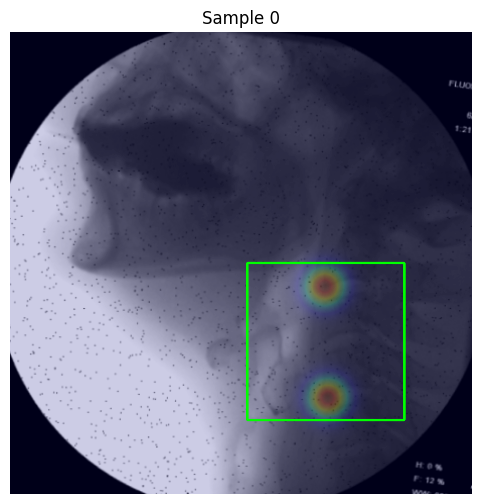

(tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0039, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0039, 0.0000, 0.0000]]]),
 [(349.1135855178892, 282.2009983780294),
  (372.40256169413374, 401.94132560666424)],
 tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.00

In [3]:
# VFSSImageDataset sem offline augmentation

transform = A.Compose([
    A.Resize(512, 512),

    A.PixelDropout(dropout_prob = 0.01,
                   p = 0.5),
    A.ShiftScaleRotate(shift_limit = 0.06,
                       scale_limit = 0.1,
                       rotate_limit = 10,
                       p = 0.5),
    A.Perspective(scale=(0.01, 0.02),
                  keep_size=True,
                  fit_output=False,
                  p=0.5),
    A.CropAndPad(px=(-30, 30),
                 p=0.5),
    A.AdvancedBlur(blur_limit= (3, 5),
                   rotate_limit= (-90, 90),
                   beta_limit= (0.5, 8.0),
                   noise_limit= (0.9, 1.1),
                   p= 0.5),
    
    #A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
    A.GaussNoise(var_limit=(0, 0.005),
                 mean=0,
                 p=0.5),   # Ruído Gaussiano

    ToTensorV2()
],
keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
)

data = VFSSImageDataset(video_frame_df = video_frame_df,
                 output_dim=(512,512),
                 transform = transform,
                 offline_augmentation = False,
                 sigma = 15)

data.plot_sample(0, False, True, True)
data[0]

In [4]:
# Criando df com augmentation (salvando as imagens)

transform_offline = A.Compose([
    A.PixelDropout(dropout_prob = 0.01, p = 0.5),
    A.ShiftScaleRotate(shift_limit = 0.06, scale_limit = 0.1, rotate_limit = 10, p = 0.5),
    A.Perspective(scale=(0.01, 0.02), keep_size=True, fit_output=False, p=0.5),
    A.CropAndPad(px=(-30, 30), p=0.5),
    A.AdvancedBlur(blur_limit= (3, 15), rotate_limit= (-90, 90), beta_limit= (0.5, 8.0), noise_limit= (0.9, 1.1), p= 0.5),
    
    A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
    A.GaussNoise(var_limit=(00.0, 100.0), mean=0, p=0.5),   # Ruído Gaussiano
    A.Resize(512, 512)
],
keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
)

new_rows_df = generate_offline_dataset(video_frame_df,
                                       transform_offline,
                                       save_dir="data/frames_augmentation",
                                       n_aug=2,
                                       debug=True)

Processando frames:   0%|          | 0/973 [00:00<?, ?it/s]

Processando frames:   5%|▌         | 52/973 [00:07<02:12,  6.93it/s]


KeyboardInterrupt: 

In [ ]:
new_rows_df

,frame_path,keypoints
0,data/frames_augmentation\v100_f10_aug1.png,"[(343.0, 259.5), (362.5, 375.5)]"
1,data/frames_augmentation\v100_f10_aug2.png,"[(332.0778402323877, 261.50943121545214), (352..."
2,data/frames_augmentation\v100_f12_aug1.png,"[(326.6355849541558, 210.9013320759165), (362...."
3,data/frames_augmentation\v100_f12_aug2.png,"[(357.4733345238476, 271.73609469585506), (368..."
4,data/frames_augmentation\v100_f13_aug1.png,"[(353.1585279282645, 223.1933325769383), (384...."
...,...,...
1941,data/frames_augmentation\v9_f40_aug2.png,"[(343.04488272055835, 169.88175550396923), (37..."
1942,data/frames_augmentation\v9_f50_aug1.png,"[(336.100509569106, 146.82184665326687), (369...."
1943,data/frames_augmentation\v9_f50_aug2.png,"[(329.1061954674762, 206.0154234000419), (362...."
1944,data/frames_augmentation\v9_f54_aug1.png,"[(323.550221021611, 170.4305300245098), (350.3..."


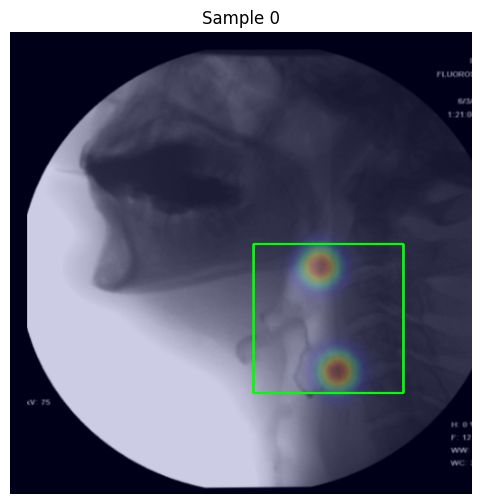

In [ ]:
# VFSSImageDataset com offline augmentation
transform = A.Compose([A.Resize(512, 512)],
                      keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

data = VFSSImageDataset(video_frame_df = new_rows_df,
                 output_dim=(512,512),
                 transform = transform,
                 offline_augmentation = True,
                 sigma = 15)

data.plot_sample(0, False, True, True)